In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

env = CartPoleCustomize()
#envs = gym.make_vec("CartPole-v1", num_envs=3, vectorization_mode="vector_entry_point")

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

cpu


In [3]:
def episode(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    with torch.no_grad():
        while not terminated and not truncated:
            # Render the environment
            #env.render()
            # Take a random action
            u, _ = actor.step(observation)
            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())
            value,_ = critic.step(observation)
            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            value_next,_ = critic_target.step(observation)

            delta = reward + gamma*value_next - value

            optimizer_actor.zero_grad(set_to_none=False)
            optimizer_critic.zero_grad(set_to_none=False)

            # actor.prop(delta*(F.one_hot(torch.tensor(action), num_classes=n_actions)-p))
            # #print(action, delta)
            # critic.prop(delta)
            # actor.backwards()
            # critic.backwards()
            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
            actor.backwardsRL(delta.item(), gamma)
            critic.prop(1.)
            critic.backwardsRL(delta.item(), gamma)

            optimizer_actor.step()
            optimizer_critic.step()

            total_reward+=reward

        hard_update(critic_target, critic)
        #soft_update(critic_target, critic, tau=0.01)

    return total_reward

@torch.no_grad()
def soft_update(target, source, tau = 0.01):
    for p_t, p in zip(target.parameters(), source.parameters()):
        p_t.mul_(1.0 - tau)
        p_t.add_(tau * p)

def hard_update(target, source):
    target.load_state_dict(source.state_dict())

In [4]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    interpolate = 4
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 0.02

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Render the environment
            #env.render()
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value

            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
            actor.backwardsRL(delta.item(), gamma)
            critic.prop(1.)
            critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t+=action_step
            if t>=0.5:
                t = 0
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)


        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        hard_update(critic_target, critic)

    return total_reward

In [5]:
actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)

num_episode = 1600

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=1e-4,#train_config["learning_rate_actor"],
    betas=(0.92, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=5e-3,#train_config["learning_rate_critic"],
    betas=(0.92, 0.999)
)

scheduler_actor = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_actor,
    T_max = num_episode,
    eta_min = 1e-7,
)

scheduler_critic = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_critic,
    T_max = num_episode,
    eta_min = 1e-6,
)

error_record = []
Cum_errors = 0.5

tensor([11., 24.,  5., 10.])
tensor([11., 24.,  5., 10.])
tensor([11., 24.,  5., 10.])


In [6]:
# Create the CartPole environment
R = 0
for i in range(num_episode):
    total_reward = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    scheduler_actor.step()
    scheduler_critic.step()
    R = 0.995*R + 0.005*total_reward
    if i%200==199:
        print(R)
# Close the environment
env.close()
print("finished")

torch.save(actor.state_dict(), general_config['save_path']+"actor.ckp")
torch.save(critic.state_dict(), general_config['save_path']+"critic.ckp")

9.378239
35.421978
100.03459
197.28215
269.83063
297.64886
325.50983
327.40695
finished


In [7]:
def episode_interpolate_adapt(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    interpolate = 4
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    plt.figure(figsize=(5,4))

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Render the environment
            #env.render()
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)

            frame = env.render()
            plt.imshow(frame)
            plt.axis("off")
            display(plt.gcf())
            clear_output(wait=True)
            time.sleep(0.001)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value

            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
            actor.backwardsRL(delta.item(), gamma)
            critic.prop(1.)
            critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t+=action_step
            if t%500==0:
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)

            # if t==600:
            #     env.set_masspole(m=0.3)


        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        hard_update(critic_target, critic)

    return total_reward

432.3093


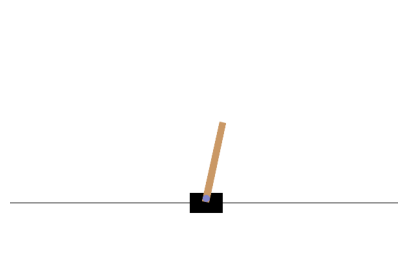

In [8]:
env = CartPoleCustomize(display=True)
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
actor.load_state_dict(torch.load(general_config['save_path']+"actor.ckp", weights_only=True))
critic.load_state_dict(torch.load(general_config['save_path']+"critic.ckp", weights_only=True))
critic_target.load_state_dict(torch.load(general_config['save_path']+"critic.ckp", weights_only=True))

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=2e-4,#train_config["learning_rate_actor"],
    betas=(0.92, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=2e-3,#train_config["learning_rate_critic"],
    betas=(0.92, 0.999)
)

total_reward = episode_interpolate_adapt(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
print(total_reward)